In [3]:
!pip install -U fg-data-profiling

Defaulting to user installation because normal site-packages is not writeable


ERROR: Ignored the following versions that require a different python version: 4.19.0 Requires-Python >=3.10,<3.14; 4.19.1 Requires-Python >=3.10,<3.14
ERROR: Could not find a version that satisfies the requirement fg-data-profiling (from versions: none)
ERROR: No matching distribution found for fg-data-profiling


In [6]:
import pandas as pd
import numpy as np
#import data_profiling
from ydata_profiling import ProfileReport

In [ ]:
uploaded=files.upload()

Saving dirty_cafe_sales.csv to dirty_cafe_sales.csv


In [7]:
df=pd.read_csv("dirty_cafe_sales.csv")

In [8]:
Profile=ProfileReport(df, title='house', explorative=True)
Profile.to_file('reporthouse.html')
files.download('reporthouse.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 41.84it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

NameError: name 'files' is not defined

In [9]:
df.dtypes

Transaction ID      object
Item                object
Quantity            object
Price Per Unit      object
Total Spent         object
Payment Method      object
Location            object
Transaction Date    object
dtype: object

In [10]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [11]:
df.shape

(10000, 8)

In [12]:
df.columns=( df.columns.str.replace(' ','_').str.lower())

In [13]:
df.head(10)

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [14]:
missing=df.isnull().mean()*100
print(missing)

transaction_id       0.00
item                 3.33
quantity             1.38
price_per_unit       1.79
total_spent          1.73
payment_method      25.79
location            32.65
transaction_date     1.59
dtype: float64


In [15]:
n_dups=df.duplicated().sum()
print(n_dups)

0


In [16]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date


In [17]:
df.isnull().sum()

transaction_id         0
item                 333
quantity             138
price_per_unit       179
total_spent          173
payment_method      2579
location            3265
transaction_date     159
dtype: int64

In [ ]:
df.head()

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [18]:
df["quantity"].unique()

array(['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan], dtype=object)

In [19]:
quantity_numeric = pd.to_numeric(df["quantity"], errors="coerce")
df[quantity_numeric.isna()]

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
20,TXN_3522028,Smoothie,ERROR,4.0,20.0,Cash,In-store,2023-04-04
55,TXN_5522862,Cookie,ERROR,1.0,2.0,Credit Card,Takeaway,2023-03-19
57,TXN_2080895,Cake,UNKNOWN,3.0,3.0,Digital Wallet,In-store,2023-04-19
66,TXN_8501819,Juice,NaN,3.0,6.0,Cash,NaN,2023-03-30
117,TXN_2148617,Juice,ERROR,3.0,9.0,Digital Wallet,UNKNOWN,2023-01-10
...,...,...,...,...,...,...,...,...
9932,TXN_8502079,Tea,UNKNOWN,1.5,3.0,Cash,NaN,2023-04-20
9935,TXN_9778251,Tea,ERROR,1.5,6.0,NaN,Takeaway,2023-11-09
9944,TXN_7495283,Cake,UNKNOWN,3.0,15.0,Credit Card,Takeaway,2023-04-14
9957,TXN_6487003,Coffee,ERROR,2.0,8.0,Credit Card,Takeaway,2023-11-15


In [20]:
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

median = df["quantity"].median()

df["quantity"] = df["quantity"].fillna(median)

In [ ]:
df["quantity"].isna().sum()

np.int64(0)

In [ ]:
df.head(21)

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3.0,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5.0,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,NaN,In-store,2023-12-31


In [21]:
df.columns

Index(['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent',
       'payment_method', 'location', 'transaction_date'],
      dtype='object')

In [22]:
df["quantity"]=pd.to_numeric(df["quantity"], errors="coerce")

In [23]:
df["item"].unique()

array(['Coffee', 'Cake', 'Cookie', 'Salad', 'Smoothie', 'UNKNOWN',
       'Sandwich', nan, 'ERROR', 'Juice', 'Tea'], dtype=object)

In [24]:
df["item"].value_counts(dropna=False)

item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64

In [25]:
item_string = pd.to_numeric(df["item"], errors="coerce")
df[item_string.isna()]

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [ ]:
df.head(10)

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,UNKNOWN,2023-10-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,NaN,In-store,2023-12-31
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
11,TXN_3051279,Sandwich,2.0,4.0,8.0,Credit Card,Takeaway,ERROR


In [26]:
df["item"] = df["item"].replace(["ERROR", "UNKNOWN"], np.nan)

In [27]:
df = df.dropna(subset=["item"])

In [28]:
df.shape

(9031, 8)

In [29]:
df["price_per_unit"].unique()

array(['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN'],
      dtype=object)

In [30]:
df = df.copy()

In [31]:
df["price_per_unit"] = df["price_per_unit"].replace(["ERROR", "UNKNOWN"], np.nan)

In [32]:
df["price_per_unit"].unique()

array(['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan], dtype=object)

In [33]:
df[df["item"] == "Juice"]

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
17,TXN_6769710,Juice,2.0,3.0,6.0,Cash,In-store,2023-02-24
19,TXN_3709394,Juice,4.0,3.0,12.0,Cash,Takeaway,2023-01-15
27,TXN_5695074,Juice,4.0,3.0,12.0,Credit Card,Takeaway,2023-04-10
43,TXN_9620080,Juice,4.0,3.0,12.0,NaN,Takeaway,2023-10-02
46,TXN_8078640,Juice,4.0,3.0,12.0,Digital Wallet,In-store,2023-11-03
...,...,...,...,...,...,...,...,...
9960,TXN_3546629,Juice,5.0,3.0,15.0,NaN,In-store,2023-03-04
9967,TXN_8563793,Juice,4.0,3.0,12.0,NaN,In-store,2023-03-26
9977,TXN_5548914,Juice,2.0,3.0,ERROR,Digital Wallet,In-store,2023-11-04
9987,TXN_1784478,Juice,5.0,3.0,15.0,Cash,NaN,2023-07-31


In [34]:
price_map = {
    "Coffee": 2,
    "Cake": 3,
    "Cookie": 1,
    "Salad": 5,
    "Smoothie": 4,
    "Sandwich": 4,
    "Tea": 1.5
}

mask = df["price_per_unit"].isna()

df.loc[mask, "price_per_unit"] = df.loc[mask, "item"].map(price_map)

In [35]:
df["total_spent"] = df["total_spent"].replace(["ERROR", "UNKNOWN"], np.nan)

In [36]:
df["total_spent"].unique()

array(['4.0', '12.0', nan, '10.0', '20.0', '16.0', '25.0', '8.0', '5.0',
       '15.0', '6.0', '2.0', '9.0', '3.0', '1.0', '7.5', '4.5', '1.5'],
      dtype=object)

In [37]:
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["price_per_unit"] = pd.to_numeric(df["price_per_unit"], errors="coerce")
df["total_spent"] = pd.to_numeric(df["total_spent"], errors="coerce")

In [38]:
mask = df["total_spent"].isna()

df.loc[mask, "total_spent"] = (df.loc[mask, "quantity"] * df.loc[mask, "price_per_unit"])

In [39]:
df.head(15)

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,NaN,2023-03-31
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,UNKNOWN,2023-10-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,NaN,In-store,2023-12-31
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
11,TXN_3051279,Sandwich,2.0,4.0,8.0,Credit Card,Takeaway,ERROR


In [40]:
df.dtypes

transaction_id       object
item                 object
quantity            float64
price_per_unit      float64
total_spent         float64
payment_method       object
location             object
transaction_date     object
dtype: object

In [41]:
df["payment_method"].value_counts(dropna=False)

payment_method
NaN               2330
Digital Wallet    2065
Cash              2046
Credit Card       2043
ERROR              286
UNKNOWN            261
Name: count, dtype: int64

In [42]:
df["payment_method"] = df["payment_method"].replace(["ERROR", "UNKNOWN"], np.nan)

In [43]:
df["payment_method"] = df["payment_method"].fillna(df["payment_method"].mode()[0])

In [44]:
df["payment_method"].value_counts(dropna=False)

payment_method
Digital Wallet    4942
Cash              2046
Credit Card       2043
Name: count, dtype: int64

In [45]:
df["location"].value_counts(dropna=False)

location
NaN         2945
Takeaway    2725
In-store    2723
ERROR        326
UNKNOWN      312
Name: count, dtype: int64

In [46]:
df["location"] = df["location"].replace(["ERROR", "UNKNOWN"], np.nan)

In [47]:
df["location"] = df["location"].fillna(df["location"].mode()[0])

In [48]:
df["location"].value_counts(dropna=False)

location
Takeaway    6308
In-store    2723
Name: count, dtype: int64

In [49]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")

In [50]:
df["transaction_date"].isna().sum()

418

In [51]:
df = df.dropna(subset=["transaction_date"])

In [52]:
df["transaction_date"].isna().sum()

0

In [53]:
df.describe()

,quantity,price_per_unit,total_spent,transaction_date
count,8613.000000,8554.000000,8612.000000,8613
mean,3.025659,2.951777,8.941419,2023-07-02 03:54:44.012539392
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-04-01 00:00:00
50%,3.000000,3.000000,8.000000,2023-07-02 00:00:00
75%,4.000000,4.000000,12.000000,2023-10-03 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.388081,1.282720,6.013125,NaN


In [54]:
df.shape


(8613, 8)

In [55]:
df.dtypes

transaction_id              object
item                        object
quantity                   float64
price_per_unit             float64
total_spent                float64
payment_method              object
location                    object
transaction_date    datetime64[ns]
dtype: object

In [56]:
df.isnull().sum()


transaction_id       0
item                 0
quantity             0
price_per_unit      59
total_spent          1
payment_method       0
location             0
transaction_date     0
dtype: int64

In [57]:
df[df["price_per_unit"].isna()]

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
161,TXN_7965998,Juice,1.0,NaN,3.0,Credit Card,In-store,2023-11-02
485,TXN_8818168,Juice,4.0,NaN,12.0,Digital Wallet,Takeaway,2023-07-20
562,TXN_3789752,Juice,3.0,NaN,9.0,Digital Wallet,Takeaway,2023-12-16
643,TXN_4266787,Juice,4.0,NaN,12.0,Credit Card,Takeaway,2023-01-12
779,TXN_4015710,Juice,4.0,NaN,12.0,Cash,Takeaway,2023-05-18
801,TXN_2393500,Juice,1.0,NaN,3.0,Credit Card,In-store,2023-12-15
834,TXN_6376175,Juice,4.0,NaN,12.0,Digital Wallet,Takeaway,2023-02-24
1017,TXN_1991104,Juice,2.0,NaN,6.0,Digital Wallet,Takeaway,2023-11-29
1124,TXN_8135614,Juice,2.0,NaN,6.0,Digital Wallet,Takeaway,2023-01-28
1256,TXN_5858988,Juice,1.0,NaN,3.0,Credit Card,Takeaway,2023-06-24


In [58]:
df.loc[
    (df["item"] == "Juice") & (df["price_per_unit"].isna()),
    "price_per_unit"
] = 3

In [59]:
df.loc[
    (df["item"] == "Juice") & (df["price_per_unit"].isna()),
    "price_per_unit"
] = 3

In [60]:
df.loc[df["total_spent"].isna(), "total_spent"] = (
    df["quantity"] * df["price_per_unit"]
)

In [61]:
Profile=ProfileReport(df, title='cafe', explorative=True)
Profile.to_file('reportcafe.html')
files.download('reportcafe.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 72.73it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

NameError: name 'files' is not defined

In [63]:
df.head(10
        )

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5.0,4.0,20.0,Credit Card,Takeaway,2023-03-31
7,TXN_6699534,Sandwich,4.0,4.0,16.0,Cash,Takeaway,2023-10-28
9,TXN_2064365,Sandwich,5.0,4.0,20.0,Digital Wallet,In-store,2023-12-31
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
12,TXN_7619095,Sandwich,2.0,4.0,8.0,Cash,In-store,2023-05-03


In [82]:
df["year"]=df["transaction_date"].dt.year
df["month"]=df["transaction_date"].dt.month

In [111]:
# Sales by year and month


sales_by_year_month = df.groupby(["year", "month"])["total_spent"].sum().reset_index()
sales_by_year_month

,year,month,total_spent
0,2023,1,6720.0
1,2023,2,5953.5
2,2023,3,6535.5
3,2023,4,6488.5
4,2023,5,6274.0
5,2023,6,6622.0
6,2023,7,6183.0
7,2023,8,6351.0
8,2023,9,6226.0
9,2023,10,6767.0


In [89]:
%matplotlib inline
import matplotlib.pyplot as plt

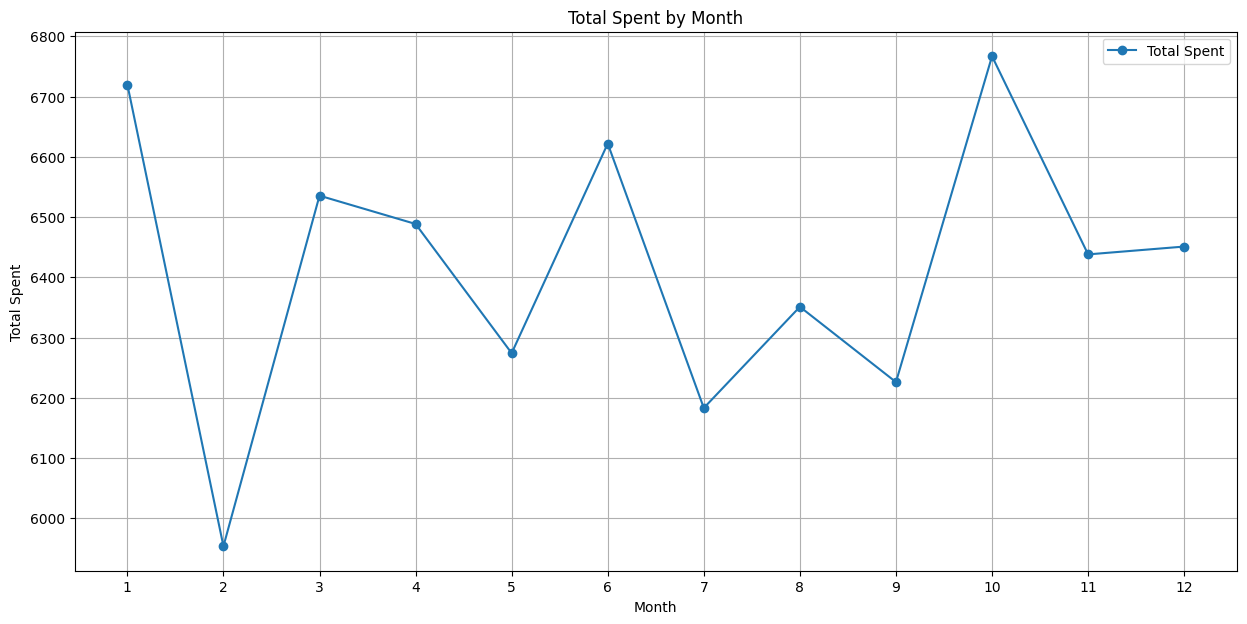

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(sales_by_year_month["month"],sales_by_year_month["total_spent"], marker="o", label="Total Spent")
plt.xticks(sales_by_year_month["month"])
plt.xlabel("Month")
plt.ylabel("Total Spent")
plt.title("Total Spent by Month")
plt.legend(loc="upper right")
plt.grid()
plt.show()

In [ ]:
# Using SQL to find the month with the highest total sales

import sqlite3

conn = sqlite3.connect(":memory:")

In [106]:
df.to_sql("cafe_sales", conn, index=False, if_exists="replace")

8613

In [109]:
query = """
SELECT
    year,
    month,
    SUM(total_spent) AS total_sales
FROM cafe_sales
GROUP BY year, month
ORDER BY total_sales DESC
LIMIT 1;
"""

result = pd.read_sql_query(query, conn)

print(result)

   year  month  total_sales
0  2023     10       6767.0


In [ ]:
# Using pandas to find the month with the highest total sales

highest_sales = sales_by_year_month.loc[sales_by_year_month["total_spent"].idxmax()]
highest_sales

year           2023.0
month            10.0
total_spent    6767.0
Name: 9, dtype: float64

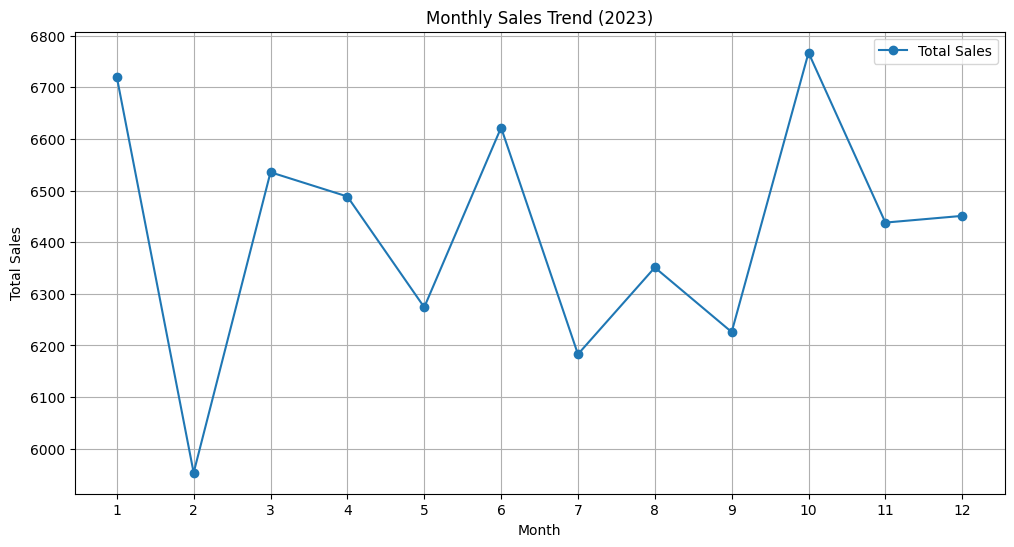

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    sales_by_year_month["month"],
    sales_by_year_month["total_spent"],
    marker="o",
    label="Total Sales"
)

plt.title("Monthly Sales Trend (2023)")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(sales_by_year_month["month"])
plt.grid(True)
plt.legend()

plt.show()

In [130]:
item_sales = df.groupby("item")["quantity"].sum().reset_index().sort_values(by="quantity", ascending=False)
item_sales

,item,quantity
1,Coffee,3425.0
3,Juice,3351.0
4,Salad,3314.0
0,Cake,3278.0
5,Sandwich,3266.0
6,Smoothie,3208.0
7,Tea,3125.0
2,Cookie,3093.0


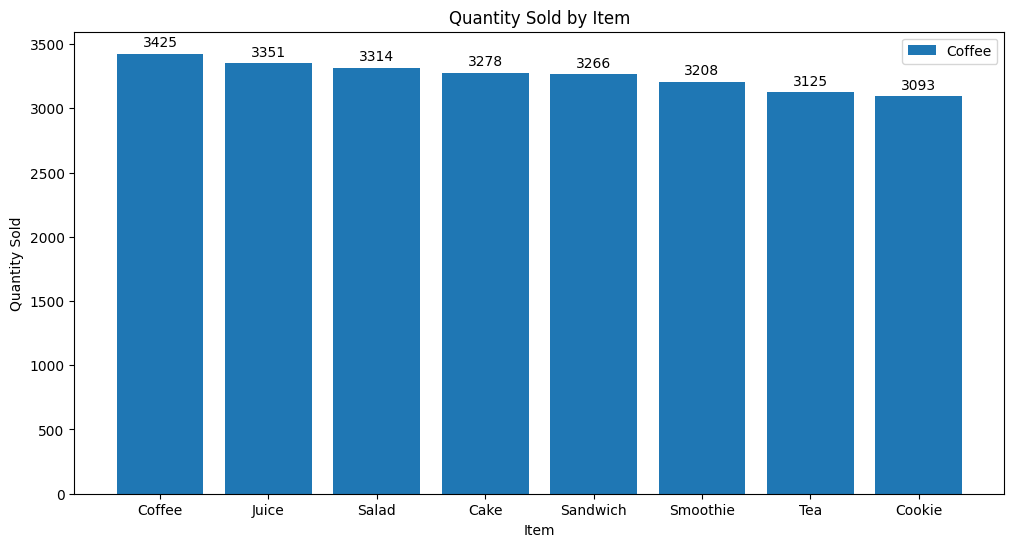

In [122]:
plt.figure(figsize=(12,6))
bars = plt.bar(item_sales["item"],item_sales["quantity"],label="Quantity Sold")
plt.bar_label(bars, padding=3)
plt.xlabel("Item")
plt.ylabel("Quantity Sold")
plt.title("Quantity Sold by Item")
plt.xticks()
plt.legend(item_sales["item"])
plt.show()

In [134]:
query = """
SELECT
    item,
    price_per_unit,
    SUM(quantity) AS total_quantity,
    SUM(total_spent) AS total_sales
FROM cafe_sales
GROUP BY item, price_per_unit
ORDER BY total_sales DESC;
"""

result = pd.read_sql_query(query, conn)

print(result)

       item  price_per_unit  total_quantity  total_sales
0     Salad             5.0          3314.0      16605.0
1  Sandwich             4.0          3266.0      13116.0
2  Smoothie             4.0          3208.0      12800.0
3     Juice             3.0          3351.0      10050.0
4      Cake             3.0          3278.0       9843.0
5    Coffee             2.0          3425.0       6844.0
6       Tea             1.5          3125.0       4669.5
7    Cookie             1.0          3093.0       3082.0


In [128]:
top_revenue_item = (df.groupby("item")["total_spent"].sum().reset_index().sort_values(by="total_spent", ascending=False))

top_revenue_item

,item,total_spent
4,Salad,16605.0
5,Sandwich,13116.0
6,Smoothie,12800.0
3,Juice,10050.0
0,Cake,9843.0
1,Coffee,6844.0
7,Tea,4669.5
2,Cookie,3082.0


In [125]:
top_revenue_item = (df.groupby("item")["total_spent"].sum().reset_index().sort_values(by="total_spent", ascending=False).head(1))

top_revenue_item

,item,total_spent
4,Salad,16605.0


In [135]:
df["payment_method"].value_counts()

payment_method
Digital Wallet    4708
Cash              1956
Credit Card       1949
Name: count, dtype: int64

In [136]:
df["month_name"] = df["transaction_date"].dt.month_name()

In [ ]:
monthly_item_sales = (
    df.groupby(["month", "month_name", "item"])["quantity"]
      .sum()
      .reset_index())

top_item_each_month = monthly_item_sales.loc[monthly_item_sales.groupby("month")["quantity"].idxmax()]
top_item_each_month

,month,month_name,item,quantity
5,1,January,Sandwich,348.0
9,2,February,Coffee,286.0
17,3,March,Coffee,322.0
27,4,April,Juice,312.0
37,5,May,Sandwich,296.0
44,6,June,Salad,302.0
50,7,July,Cookie,296.0
57,8,August,Coffee,299.0
70,9,September,Smoothie,295.0
73,10,October,Coffee,339.0
